In [122]:
pip install -r ../requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.8/551.8 kB 669.7 kB/s  0:00:00m-:--:--
Note: you may need to restart the kernel to use updated packages.


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


In [ ]:
import os
import re
import unicodedata
import pandas as pd
import numpy as np
from tqdm import tqdm
# ==========================================
# CONFIGURATION (DRY: Centralized Constants)
# ==========================================
class Config:
    """Centralized configuration constants."""
    
    # Paths
    # BASE_DIR setup for notebook
    BASE_DIR = '..'
    DATASET_DIR = os.path.join(BASE_DIR, 'datasets')
    DEFAULT_INPUT_FILE = os.path.join(DATASET_DIR, 'comments_from_scraping_new.csv')
    DEFAULT_OUTPUT_FILE = os.path.join(DATASET_DIR, 'comments_labeled_final.csv')
    
    # ML Parameters
    MAX_FEATURES = 20000
    SEQUENCE_LENGTH = 50
    EMBEDDING_DIM = 64
    EPOCHS = 8
    BATCH_SIZE = 128
    VALIDATION_SPLIT = 0.2
    AI_CONFIDENCE_THRESHOLD = 0.6
    
    # Classification thresholds
    JUDOL_SCORE_THRESHOLD = 3
    
    # URL Patterns
    URL_PATTERN = r'(https?://\S+|www\.\S+)'
    SAFE_DOMAINS = [r'youtube\.com', r'youtu\.be', r'google\.com', r'facebook\.com', r'instagram\.com']


In [ ]:
# ==========================================
# TEXT NORMALIZER (SRP: Text Processing)
# ==========================================
class TextNormalizer:
    """Handles all text normalization operations."""
    
    # Judol emojis for detection
    JUDOL_EMOJIS = ['🎰', '💰', '💵', '💸', '🎲', '💎']
    
    def __init__(self):
        self._unicode_map = self._build_unicode_map()
    
    def _build_unicode_map(self) -> dict:
        """Build mapping from fancy unicode to ASCII letters."""
        mapping = {}
        
        # Helper to add character ranges
        def add_range(start: int, chars: str, to_lower: bool = True):
            for i, c in enumerate(chars):
                mapped = c.lower() if to_lower else c
                mapping[chr(start + i)] = mapped
        
        # Mathematical styles (Bold, Italic, etc.)
        styles = [
            (0x1D400, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'),  # Bold Upper
            (0x1D41A, 'abcdefghijklmnopqrstuvwxyz'),  # Bold Lower
            (0x1D434, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'),  # Italic Upper
            (0x1D44E, 'abcdefghijklmnopqrstuvwxyz'),  # Italic Lower
            (0x1D468, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'),  # Bold Italic Upper
            (0x1D482, 'abcdefghijklmnopqrstuvwxyz'),  # Bold Italic Lower
            (0x1D49C, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'),  # Script Upper
            (0x1D4B6, 'abcdefghijklmnopqrstuvwxyz'),  # Script Lower
            (0x1D5D4, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'),  # Sans-Serif Bold Upper
            (0x1D5EE, 'abcdefghijklmnopqrstuvwxyz'),  # Sans-Serif Bold Lower
            (0x1D670, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'),  # Monospace Upper
            (0x1D68A, 'abcdefghijklmnopqrstuvwxyz'),  # Monospace Lower
            (0x1D504, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'),  # Fraktur Upper
            (0x1D51E, 'abcdefghijklmnopqrstuvwxyz'),  # Fraktur Lower
            (0x1D538, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'),  # Double-Struck Upper
            (0x1D552, 'abcdefghijklmnopqrstuvwxyz'),  # Double-Struck Lower
        ]
        
        for start, chars in styles:
            add_range(start, chars, to_lower=True)
        
        # Digit styles
        add_range(0x1D7EC, '0123456789', to_lower=False)  # Sans-Serif Bold Digits
        add_range(0x1D7CE, '0123456789', to_lower=False)  # Bold Digits
        
        # Special character sets
        add_range(0x1F1E6, 'abcdefghijklmnopqrstuvwxyz', to_lower=False)  # Regional Indicators
        add_range(0x24B6, 'abcdefghijklmnopqrstuvwxyz', to_lower=False)   # Circled Capital
        add_range(0x24D0, 'abcdefghijklmnopqrstuvwxyz', to_lower=False)   # Circled Small
        add_range(0x1F150, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ')  # Enclosed Circled
        add_range(0x1F170, 'ABCDEFGHIJKLMNOPQRSTUVWXYZ')  # Enclosed Squared
        
        # Greek and Cyrillic homoglyphs
        homoglyphs = {
            'α': 'a', 'Α': 'a', 'β': 'b', 'Β': 'b', 'σ': 's', 'Σ': 's',
            'τ': 't', 'Τ': 't', 'δ': 'd', 'Δ': 'd', 'ω': 'w', 'Ω': 'w',
            'ε': 'e', 'η': 'n', 'ι': 'i', 'κ': 'k', 'λ': 'l', 'μ': 'm',
            'ν': 'n', 'ο': 'o', 'π': 'p', 'ρ': 'r', 'υ': 'u', 'φ': 'f',
            'χ': 'x', 'ψ': 'ps', 'ζ': 'z', 'ά': 'a', 'έ': 'e', 'ή': 'n',
            'ί': 'i', 'ό': 'o', 'ύ': 'u', 'ώ': 'o',
            # Cyrillic
            'А': 'a', 'а': 'a', 'В': 'b', 'Е': 'e', 'е': 'e', 'К': 'k',
            'М': 'm', 'Н': 'h', 'О': 'o', 'о': 'o', 'Р': 'p', 'р': 'p',
            'С': 'c', 'с': 'c', 'Т': 't', 'т': 't', 'У': 'y', 'у': 'y',
            'Х': 'x', 'х': 'x'
        }
        mapping.update(homoglyphs)
        
        # Common obfuscation characters
        obfuscation = {
            '@': 'a', '$': 's', '†': 't', '҉': '', 'ñ': 'n', 'Ä': 'a',
            'Ö': 'o', 'ǟ': 'a', 'ʀ': 'r', 'ա': 'w', 'ռ': 'n', 'ȶ': 't',
            'օ': 'o', 'ή': 'n', 'Ŵ': 'w', 'Ⓞ': 'o', '丅': 't', 'ᗩ': 'a',
            'ᗯ': 'w', '𝓣': 't', '𝓽': 't', '𝐍': 'n', '𝒶': 'a', '𝕒': 'a',
            '𝕨': 'w', '乃': 'b', 'ﾑ': 'a', 'ｲ': 't', '尺': 'r', '乇': 'e',
            'り': 'd', 'ℓ': 'l', 'ɴ': 'n', 'ρ': 'p',
            '\u20E3': '', '\uFE0F': '',  # Keycaps & VS
            # Small Capitals
            'ᴀ': 'a', 'ʙ': 'b', 'ᴄ': 'c', 'ᴅ': 'd', 'ᴇ': 'e', 'ꜰ': 'f',
            'ɢ': 'g', 'ʜ': 'h', 'ɪ': 'i', 'ᴊ': 'j', 'ᴋ': 'k', 'ʟ': 'l',
            'ᴍ': 'm', 'ɴ': 'n', 'ᴏ': 'o', 'ᴘ': 'p', 'ꞯ': 'q', 'ʀ': 'r',
            'ꜱ': 's', 'ᴛ': 't', 'ᴜ': 'u', 'ᴠ': 'v', 'ᴡ': 'w', 'ʏ': 'y', 'ᴢ': 'z'
        }
        mapping.update(obfuscation)
        
        return mapping
    
    def normalize(self, text: str) -> str:
        """Normalize text for pattern matching."""
        if pd.isna(text):
            return ""
        text = str(text)
        
        # Remove zero-width characters
        text = re.sub(r'[\u200b\u200c\u200d\u200e\u200f\u2060\ufeff]', '', text)
        
        # Apply unicode mapping
        text = ''.join(self._unicode_map.get(c, c) for c in text)
        
        # Standard normalization
        text = unicodedata.normalize('NFKD', text)
        text = "".join(c for c in text if not unicodedata.combining(c))
        text = unicodedata.normalize('NFKC', text)
        
        # Lowercase and clean
        text = text.lower()
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        
        return text.strip()
    
    def normalize_leetspeak(self, text: str) -> str:
        """Normalize leetspeak for keyword matching."""
        t = self.normalize(text)
        leetspeak = str.maketrans('0134578@$', 'oiyeastba')
        return t.translate(leetspeak)
    
    def normalize_aggressive(self, text: str) -> str:
        """Aggressive normalization - remove ALL non-alphanumeric."""
        return re.sub(r'[^a-z0-9]', '', self.normalize(text))
    
    def count_judol_emojis(self, text: str) -> int:
        """Count gambling-related emojis."""
        if pd.isna(text):
            return 0
        return sum(1 for e in self.JUDOL_EMOJIS if e in str(text))
    
    def has_fancy_unicode(self, text: str) -> bool:
        """Check if text contains fancy unicode characters."""
        if pd.isna(text):
            return False
        return any(
            (ord(c) > 0x1F00 or (0x1D00 <= ord(c) <= 0x1DBF) or (0x0300 <= ord(c) <= 0x036F))
            for c in str(text)
        )


In [ ]:
# ==========================================
# PATTERN MATCHER (SRP: Pattern Detection + DRY: Consolidated Patterns)
# ==========================================
class PatternMatcher:
    """Handles all pattern matching for gambling content detection."""
    
    # Judol Keywords
    KEYWORDS = [
        'slot', 'gacor', 'maxwin', 'scatter', 'sceter', 'scater', 'jackpot',
        'pragmatic', 'pgsoft', 'pg soft', 'habanero', 'spadegaming', 'joker123',
        'rtp live', 'bocoran slot', 'freespin', 'puteran', 'withdraw', 'depo ',
        'modal receh', 'cuan', 'new member', 'newmember', 'sbobet',
        'jepi', 'jpnya', 'jepee', 'jekpot', 'jekpod',
    ]
    
    # Judol Phrases
    PHRASES = [
        'cari di google', 'search di google', 'ketik di google',
        'wd ', 'wd gede', 'wd lancar', 'modal receh', 'modal kecil',
        'modal 10k', 'modal 20k', 'modal 25k', 'modal 30k', 'modal 35k',
        'modal 50k', 'modal 100k', 'x500', 'x1000', 'x5000',
        'situs terpercaya', 'situs resmi', 'link resmi',
        'auto wd', 'auto jp', 'auto cuan', 'auto maxwin',
        'dijamin wd', 'pasti bayar', 'pasti wd', 'hoki hari ini',
        'gacor hari ini', 'jp hari ini', 'mabar slot',
        'gacor parah', 'jackpot besar', 'main togel', 'suka togel', 'main slot',
        'salam hoki', 'salam jp', 'salam cuan', 'salam gacor',
        'baru join', 'baru daftar', 'baru gabung', 'member baru',
        'langsung menang', 'langsung jp', 'langsung wd', 'langsung dapat',
        'scatter turun', 'scatter hitam', 'scatter bertubi', 'dikasih maxwin',
        'nikmati bonus', 'bonus pertama', 'bonus new member',
        '1jt', '2jt', '3jt', '5jt', '10jt', '15jt', '20jt', '25jt', '30jt',
        '35jt', '50jt', '100jt', '200jt', '500jt',
        '1 juta', '2 juta', '5 juta', '10 juta', '20 juta', '50 juta', '100 juta',
        'ratusan juta', 'puluhan juta', 'jutaan', 'jt modal',
    ]
    
    # Unicode brackets used in spam
    SPAM_BRACKETS = ['【', '】', '〖', '〗', '『', '』', '「', '」', '꧁', '꧂']
    
    # Excluded words (not gambling)
    EXCLUDED_WORDS = [
        'totoan', 'gerrard', 'gerard', 'edward', 'forward', 'reward',
        'password', 'keyboard', 'record', 'ahmad', 'sad', 'bad',
        'mad', 'dad', 'had', 'add', 'odd', 'god', 'red', 'bed', 'led',
        'kid', 'bid', 'rid', 'mid', 'lid', 'old', 'cold', 'gold', 'bold',
        'sold', 'told', 'hold', 'fold', 'mold', 'card', 'hard', 'yard',
        'lord', 'word', 'bird', 'third', 'heard', 'world', 'child',
        'friend', 'behind', 'mind', 'kind', 'find', 'blind', 'wind',
        'sound', 'ground', 'found', 'bound', 'pound', 'alucard',
        'legend', 'island', 'hand', 'band', 'land', 'sand', 'brand',
        'stand', 'grand', 'demand', 'command', 'expand', 'load',
        'road', 'head', 'dead', 'read', 'lead', 'bread', 'spread', 'thread',
        'instead', 'ahead', 'overhead', 'upload', 'download', 'period', 'round',
        'squad', 'end', 'send', 'spend', 'trend', 'friend', 'blend', 'defend',
        'liquid', 'seagood', 'good', 'food', 'mood', 'blood', 'flood', 'wood', 'hood',
        'could', 'would', 'should', 'need', 'feed', 'seed', 'speed', 'weed', 'indeed',
        'build', 'field', 'yield', 'shield', 'wild', 'guild', 'valid', 'solid', 'stupid',
        'rapid', 'vivid', 'acid', 'avoid', 'void', 'roid', 'android', 'paid',
        'sed', 'fled', 'bled', 'sped', 'shed', 'wed', 'ted', 'ned',
        'c4d', 'c3d', 'r3d', 'b3d', 's3d', 'a4d',
        'tenaga', 'olahraga', 'sinaga', 'kenanga', 'tetangga', 'mangga',
        'sitoto', 'dewanya', 'dewata', 'dewi', 'dewa19', 'dewasa',
    ]
    
    # Site patterns (DRY: Consolidated from SITE_PATTERNS and EXPERT_SITE_PATTERNS)
    SITE_PATTERNS = [
        # General patterns
        r'\b(?!(?:si|fan|so|ka))[\w]{2,}toto\b',
        r'\b\w{2,}slot\b', r'\b\w{2,}togel\b',
        r'\btoto\w{2,}\b',
        r'\b[a-z]{2,}(?:4d|777|88)\b', r'\b[a-z]+\d+d\b',
        r'\b\w{2,}hoki\b', r'\b\w+naga\b', r'\bgaruda\s*hoki\b',
        r'\bga\s*ruda\s*ho\s*ki\b', r'\bruda\s*ho\s*ki\b',
        r'\b[a-z]{3,}(?:138|303|369|898|123|76|62|77|98)\b',
        r'\bharta\d+\b', r'\bplaytoto\d+\b', r'\bbonus\w+\b', r'\bdewa\w{2,}\b',
        r'\barwana', r'\bplazabola\b', r'\bmona\s*4d\b',
        r'\bkino\w*d\b', r'\blazadatoto\b', r'\bshopetoto\b',
        r'\bpulauwin\b', r'\baero\w*\d+\b', r'\bvisi\s*4d\b',
        r'\bdora\s*\d+\b', r'\bambil\s*4d\b', r'\bxuxu\s*4d\b',
        r'\bgacorwin\w*\b', r'\bpusatwin\b',
        r'\bipototo\b', r'\bometoto\b', r'\bpstoto\d*\b', r'\btotospin\b',
        r'\bevostoto\b', r'\btotocc\b',
        r'\bmini\d{3,}\b', r'\brtpwin\b', r'\bgopek\d+\b', r'\bbibit\d+\b',
        r'\bphoenix\d+\b', r'\bligamansion\d*\b', r'\bmbak\d+[a-z]*\b',
        r'\bdewadora\b', r'\bagustoto\b', r'\bmuraipoker\b', r'\bpaste\d*[a-z]*\b',
        r'\bkurirslot\b', r'\bweton\W*\d+\b', r'\bpp\s*ho\s*ki\b',
        r'\bzoom\d+\b', r'\bbandargaruda\b', r'\bsukajp\b', r'\bmamajitu\b',
        r'\bvhoki\b', r'\b5unsur\b', r'\bga\s*ru\s*da\s*ho\s*k[i]?\b',
        r'\bligakembar\b', r'\bfilabola\b',
        r'\bdibet\d+[a-z]*\b', r'\bjuno\d+[a-z]*\b',
        r'\bdewa\s*dora\b',
        r'\bjepi\b', r'\bjepee\b', r'\bjekpot\b',
        # Expert patterns (consolidated)
        r'MINI\d{3,}', r'MBAK[A-Z0-9]{0,10}\d+', r'LIGAMANSION\d*',
        r'DORA\d{2,}', r'KYT\d+', r'DOGRA\d+', r'PASTE(L?)\d+',
        r'KURIRSLOT', r'ARWANA\w+', r'PLAZABOLA', r'PROBET',
        r'PLAY\d+', r'VIP\d+', r'WAYANG\d+', r'TOTAL\d+', r'JOKER\d+',
        r'CROWN\d+', r'ROYAL\d+', r'WOKEBET', r'MAJOR\s*\d+', r'PESIAR\d+',
        r'SERU\d+', r'DAYAK\s*\d+', r'TARGET\d+', r'KANGJP\d*', r'DOYAN\d+',
        r'DUO\s*GAMING', r'4RABET', r'AMBIL\d+', r'WE\s*TOGEL',
        r'SUPER\s*MONEY\d*', r'HOKI\d+', r'CIUM\d+', r'KOBE\d+', r'ALEXIS\d+',
        r'XUXU\d+', r'PULAU\d+', r'PRIMBON\d+', r'TIMO\d+', r'GELORA\d+',
        r'LAUTAN(SLOT|TOTO|POKER|WIN|BET|\d+)', r'KOPI(SLOT|TOTO|\d+)',
        r'PSTOTO\d*', r'SEKALI\d+', r'MANUT\d+', r'CIDUK\d+|CIDUK[-]?JP',
        r'CUKONG\d+', r'DENYUT\d+', r'HOLYWIN', r'DOYAN\s*TOTO',
        r'D\s*U\s*O?\s*G\s*A\s*M\s*I\s*N\s*G', r'SAMBAR\d+|SAMBARJP',
        r'MONET\d+|MONET[-]?\d+', r'OJOL\d+', r'GLOBAL\d+',
        r'JEPOR\d+|JEPOR[-]?\d+', r'REKOR\d+|REKOR[-]?\d+', r'RP\d+',
        r'TOHIR\d+', r'PLAYTOTO\d*', r'AREA\s*MAIN', r'KAWASAN\s*TEMPUR',
        r'ARENA\s*TEMPUR', r'AUTO\s*TURBO', r'TIKET\d+',
    ]
    
    # Specific site names for obfuscation check
    SITE_NAMES = [
        'PULAUWIN', 'ARWANA', 'GACORWIN', 'LAZADATOTO', 'SHOPETOTO',
        'GARUDAHOKI', 'PLAZABOLA', 'ARWANATOTO', 'KYT4D',
        'SENDAL4D', 'SAJAK4D', 'PELATIH4D', 'VISI4D', 'SOR76',
        'DOYANTOTO', 'PREMIERSLOT88', 'TOTOTAROT', 'LOHANSLOT',
        'GIAT777', 'TOGEL62', 'SABDA4D', 'AERO88', 'BERKAH99',
        'LESTI77', 'BUKIT4D', 'PUSATWIN', 'PULAU777', 'PUIAU777',
        'PUIAU', 'PULAUTUJUH', 'DYANTOTO', 'DRWANA', 'DRWANATOTO', 'DRWANATSTS',
        'MINI1221', 'RTPWIN', 'GOPEK500', 'BIBIT168', 'PHOENIX638',
        'LIGAMANSION', 'MBAK4D', 'DEWADORA', 'AGUSTOTO', 'MURAIPOKER',
        'PASTE4D', 'KURIRSLOT', 'PSTOTO99',
        'ZOOM555', 'BANDARGARUDA', 'SUKAJP', 'MAMAJITU', 'VHOKI', '5UNSUR', 'SUKU88',
    ]
    
    # Anti-gambling keywords
    ANTI_KEYWORDS_STRONG = [
        'berhenti main', 'stop judi', 'jijik', 'tobat', 'penipuan', 'tipu',
        'bohong', 'haram', 'dosa', 'setan', 'iblis', 'jauhi', 'korban',
        'miskin', 'melarat', 'hancur', 'bangkrut', 'neraka', 'siksa'
    ]
    
    PROMO_TACTICS = [
        'jangan bilang', 'gak nyuruh', 'awalnya takut', 'takut rungkad',
        'pernah rungkad', 'gak rugi', 'tidak rugi', 'tanpa rugi',
        'cape ditipu', 'cape rungkad', 'tempat jujur', 'situs jujur'
    ]
    
    def __init__(self, normalizer: TextNormalizer):
        self.normalizer = normalizer
        self._exclusion_pattern = re.compile(r'\b(' + '|'.join(self.EXCLUDED_WORDS) + r')\b')
        self._site_patterns_compiled = [re.compile(p, re.IGNORECASE) for p in self.SITE_PATTERNS]
    
    def _check_any_pattern(self, text: str, patterns: List[str]) -> bool:
        """DRY: Generic pattern checking helper."""
        return any(p in text for p in patterns)
    
    def has_keywords(self, text: str) -> bool:
        """Check for gambling keywords."""
        t = self.normalizer.normalize_leetspeak(text)
        return self._check_any_pattern(t, self.KEYWORDS)
    
    def has_phrases(self, text: str) -> bool:
        """Check for gambling phrases."""
        t = self.normalizer.normalize_leetspeak(text)
        # Exclude subscriber/viewer context
        subscriber_context = ['subs', 'subscriber', 'views', 'penonton', 'followers', 'like']
        if any(w in t for w in subscriber_context):
            return False
        return self._check_any_pattern(t, self.PHRASES)
    
    def has_unicode_brackets(self, text: str) -> bool:
        """Check for spam-style unicode brackets."""
        if pd.isna(text):
            return False
        return any(b in str(text) for b in self.SPAM_BRACKETS)
    
    def has_site_pattern(self, text: str) -> bool:
        """Check for gambling site patterns."""
        t = self.normalizer.normalize(text)
        t = self._exclusion_pattern.sub(' ', t)
        return any(p.search(t) for p in self._site_patterns_compiled)
    
    def has_judol_money(self, text: str) -> bool:
        """Check for money patterns common in gambling promotion."""
        t = self.normalizer.normalize(text)
        patterns = [r'\d{2,}jt\b', r'\d{2,}\s*juta\b']
        legit_context = [
            'gaji', 'tunjangan', 'harga', 'bayar', 'hutang', 'utang', 'dpr', 'pejabat',
            'korupsi', 'subscribe', 'subcribe', 'subscriber', 'views', 'penonton',
            'followers', 'kekayaan', 'triliun', 'miliar', 'saham', 'dollar', 'bisnis',
            'perusahaan', 'transfer', 'tf ', 'kirim', 'pinjam', 'nyadar', 'baru'
        ]
        if any(w in t for w in legit_context):
            return False
        return any(re.search(p, t, re.IGNORECASE) for p in patterns)
    
    def has_obfuscated_site_name(self, text: str) -> bool:
        """Check for obfuscated site names with unicode/fancy characters."""
        if pd.isna(text):
            return False
        text_str = str(text)
        text_upper = text_str.upper()
        
        # Check for fancy unicode
        if not self.normalizer.has_fancy_unicode(text_str):
            # Only check specific patterns for non-fancy text
            text_clean = re.sub(r'[\s\u200b\u200c\u200d\ufeff]', '', text_upper)
            specific_patterns = [
                r'MINI\d{3,}', r'SERU\d+', r'KYT\d+D?', r'GARUDA.?HO.?KI',
                r'PLAZA.?BOLA', 'PULAUWIN', 'ARWANATOTO', 'KURIRSLOT',
                'BATRE4D', 'BATRE4Y', 'SUKU88'
            ]
            for pattern in specific_patterns:
                if pattern.isalpha() and pattern.isupper():
                    if pattern in text_clean:
                        return True
                elif re.search(pattern, text_clean, re.IGNORECASE):
                    return True
            return False
        
        # Normalize for site pattern matching
        normalized = []
        for char in text_str:
            if char in self.normalizer._unicode_map:
                normalized.append(self.normalizer._unicode_map[char])
            else:
                normalized.append(char)
        text_normalized = ''.join(normalized).upper()
        
        text_normalized_spaced = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text_normalized)
        text_clean = re.sub(r'[\s\u200b\u200c\u200d\ufeff]', '', text_normalized)
        text_clean = re.sub(r'[^A-Z0-9]', '', text_clean)
        
        # Check if SLOT/TOTO is standalone
        slot_is_standalone = re.search(r'\bSLOT\b', text_normalized_spaced) and not re.search(r'\w{2,}SLOT', text_normalized_spaced)
        toto_is_standalone = re.search(r'\bTOTO\b', text_normalized_spaced) and not re.search(r'\w{2,}TOTO', text_normalized_spaced)
        
        site_patterns = [
            r'\w{2,}4D\d*\b', r'\w{2,}TOTO\b', r'\w{2,}TOGEL\b', r'T[O0]GEL\d+',
            r'\w+WIN\b', r'\w{2,15}SLOT\b', r'\w{3,}88\b', r'\w{3,}168\b',
            r'\w{2,}369\b', r'\w{3,}898\b', r'\w{3,}789\b', r'\w{3,}123\b',
            r'\w{3,}138\b', r'\w{3,}777\b', r'\w{3,}888\b',
            r'SERU69\b', r'DORA77\b', r'LESTI77\b', r'GIAT77[7]?\b',
        ]
        
        for pattern in site_patterns:
            if slot_is_standalone and 'SLOT' in pattern and r'\w' in pattern:
                continue
            if toto_is_standalone and 'TOTO' in pattern and r'\w' in pattern:
                continue
            if re.search(pattern, text_clean, re.IGNORECASE):
                return True
        
        # Check specific site names
        for name in self.SITE_NAMES:
            if name in text_clean:
                return True
        
        return False
    
    def has_spaced_site_name(self, text: str) -> bool:
        """Check for site names with spaces between letters."""
        if pd.isna(text):
            return False
        text_norm = self.normalizer.normalize(text).upper()
        text_clean = re.sub(r'[^A-Z0-9]', '', text_norm)
        
        for t in self.SITE_NAMES:
            if t in text_clean:
                regex = r'.*'.join(re.escape(c) for c in t)
                if re.search(regex, text_norm, re.IGNORECASE):
                    return True
        return False
    
    def check_expert_pattern(self, text: str) -> bool:
        """Check for expert site patterns including URLs."""
        norm = self.normalizer.normalize(text)
        
        # Standard check
        if any(re.search(p, norm, re.IGNORECASE) for p in self.SITE_PATTERNS):
            return True
        
        # Aggressive check
        norm_aggressive = self.normalizer.normalize_aggressive(text)
        if any(re.search(p, norm_aggressive, re.IGNORECASE) for p in self.SITE_PATTERNS):
            return True
        
        # Suspicious URLs
        urls = re.findall(Config.URL_PATTERN, str(text).lower())
        for url in urls:
            is_safe = any(re.search(safe, url) for safe in Config.SAFE_DOMAINS)
            if not is_safe:
                return True
        
        return False
    
    def is_likely_anti_gambling(self, text: str) -> bool:
        """Check if comment is genuinely anti-gambling."""
        text = str(text).lower()
        
        if any(tactic in text for tactic in self.PROMO_TACTICS):
            return False
        
        if any(k in text for k in self.ANTI_KEYWORDS_STRONG):
            if 'jangan ragu' in text or 'jangan takut' in text or 'jangan lupa' in text:
                return False
            
            negations = ['bukan', 'ga', 'gak', 'tidak', 'gapernah', 'bkn']
            words = text.split()
            for i, word in enumerate(words):
                if any(k in word for k in self.ANTI_KEYWORDS_STRONG):
                    start = max(0, i-3)
                    context = words[start:i]
                    if any(neg in context for neg in negations):
                        return False
            return True
        
        return False


In [ ]:
# ==========================================
# JUDOL CLASSIFIER (SRP: Classification Logic)
# ==========================================
class JudolClassifier:
    """Handles classification logic for gambling content."""
    
    # Context for band TOTO or person name
    BAND_CONTEXT = [
        'lagu', 'musik', 'album', 'rosanna', 'africa', 'hold you back',
        'dewa 19', 'dewa19', 'band', 'personil', 'drummer', 'guitarist',
        'feat ', 'cover', 'mendengar', 'dengerin', 'listen', 'bermusik',
        'channel', 'menarik', 'sah good', 'seagood', 'terbaik',
        'penggemar', 'suka banget', 'salam dari', 'salam untuk'
    ]
    
    PERSON_CONTEXT = [
        'pak toto', 'bapak toto', 'otto toto', 'toto wolff', 'kekayaan',
        'data center', 'dci', 'pionir', 'praktisi', 'wawancara',
        'undang', 'podcast', 'diundang', 'beliau', 'teknologi',
        'vendor', 'engineer', 'kerjain', 'motivasi',
        'si toto', 'dasar si toto', 'ah toto', 'woua toto', 'thanks toto',
        'grazie toto', 'takurany toto', 'hulu tah', 'ruksak toto',
        'jebleh ku', 'beban sitoto', 'totoka', 'totoale',
        'hulu ruksak', 'tangkurak', 'ketua', 'f1', 'formula 1',
        'mercedes', 'red bull', 'grazie', 'grande', 'el grande',
        'morocco', 'rap', 'maroc', 'pablo', 'game', 'minecraft', 'kang sine'
    ]
    
    ESPORTS_CONTEXT = [
        'onic', 'evos', 'rrq', 'alter ego', 'bigetron', 'aura',
        'geek fam', 'nxl', 'aerowolf', 'sonic', 'mpl', 'esports',
        'mobile legends', 'ml', 'm series', 'playoff'
    ]
    
    GACOR_BIRD_CONTEXT = [
        'burung', 'kicau', 'suara', 'lagu', 'nyanyian', 'karaoke',
        'murai', 'kenari', 'cucak', 'pleci', 'love bird', 'cendet'
    ]
    
    def __init__(self, normalizer: TextNormalizer, pattern_matcher: PatternMatcher):
        self.normalizer = normalizer
        self.matcher = pattern_matcher
    
    def is_band_or_person_toto(self, text: str) -> bool:
        """Check if 'toto' refers to band TOTO or person name."""
        if pd.isna(text):
            return False
        text_lower = str(text).lower()
        
        if 'toto' not in text_lower:
            return False
        
        if self.matcher.has_site_pattern(text):
            return False
        
        text_normalized = self.normalizer.normalize(text).upper()
        text_clean = re.sub(r'[^A-Z0-9]', '', text_normalized)
        if re.search(r'[A-Z]{2,}TOTO', text_clean):
            return False
        
        has_band_context = any(w in text_lower for w in self.BAND_CONTEXT)
        has_person_context = any(w in text_lower for w in self.PERSON_CONTEXT)
        has_esports_context = any(w in text_lower for w in self.ESPORTS_CONTEXT)
        
        if 'toto' in text_lower:
            if has_band_context or has_person_context or has_esports_context:
                return True
            casual_patterns = [
                r'\bsi toto\b', r'\btoto\s*😂', r'\btoto\s*😭',
                r'\btoto\s*🔥', r'\btoto\s*👏', r'ah toto',
                r'aah toto', r'thanks toto', r'grazie toto',
                r'suka.{0,10}toto', r'toto.{0,10}❤'
            ]
            for p in casual_patterns:
                if re.search(p, text_lower):
                    return True
        
        return has_band_context or has_person_context
    
    def is_anti_gambling_weak(self, text: str) -> bool:
        """Check if comment is warning/criticism about gambling."""
        if pd.isna(text):
            return False
        text_lower = str(text).lower()
        
        if self.matcher.has_site_pattern(text):
            return False
        
        anti_phrases = [
            'berhenti judi', 'stop judi', 'jangan judi', 'bahaya judi',
            'di tipu', 'ditipu', 'tipu', 'penipu', 'penipuan',
            'scam', 'scammer', 'bodong', 'palsu',
            'jangan main', 'jangan percaya', 'hati-hati', 'awas',
            'rugi', 'bangkrut', 'habis', 'korban', 'tobat',
            'belum dibayar', 'tidak dibayar', 'ga dibayar',
        ]
        return any(phrase in text_lower for phrase in anti_phrases)
    
    def classify(self, text: str) -> int:
        """Classify text as gambling (1) or not (0)."""
        if pd.isna(text) or str(text).strip() == "":
            return 0
        
        text = str(text).lower()
        
        if self.is_band_or_person_toto(text):
            return 0
        
        score = 0
        if self.matcher.has_keywords(text): score += 2
        if self.matcher.has_phrases(text): score += 3
        if self.matcher.has_unicode_brackets(text): score += 3
        if self.matcher.has_site_pattern(text): score += 3
        if self.matcher.has_judol_money(text): score += 2
        if self.matcher.has_obfuscated_site_name(text): score += 3
        if self.matcher.has_spaced_site_name(text): score += 3
        if self.normalizer.count_judol_emojis(text) >= 2: score += 1
        
        text_normalized = self.normalizer.normalize(text)
        
        # "mending ... daripada ... slot" comparison (not promo)
        if ('slot' in text_normalized and 'mending' in text_normalized and
            not self.matcher.has_site_pattern(text) and
            not self.matcher.has_obfuscated_site_name(text)):
            if any(w in text_normalized for w in ['daripada', 'drpd', 'timbang', 'ketimbang', 'dari pada']):
                score -= 4
        
        # Game lore (Zeus + Kratos)
        if 'kratos' in text and ('zeus' in text or 'olympus' in text) and not self.matcher.has_site_pattern(text):
            score -= 4
        
        # "gacor" context check
        if 'gacor' in text:
            if any(w in text for w in self.GACOR_BIRD_CONTEXT):
                score -= 4
            elif (not self.matcher.has_site_pattern(text) and
                  not self.matcher.has_obfuscated_site_name(text) and
                  not self.matcher.has_phrases(text)):
                if 'slot' not in text and 'maxwin' not in text and not self.matcher.has_judol_money(text):
                    score -= 2
        
        if self.is_anti_gambling_weak(text):
            score -= 4
        
        return 1 if score >= Config.JUDOL_SCORE_THRESHOLD else 0


In [ ]:
# ==========================================
# LABELING PIPELINE (SRP: ML Pipeline & I/O)
# ==========================================
class LabelingPipeline:
    """Handles ML pipeline and file I/O."""
    
    def __init__(self, classifier: JudolClassifier):
        self.classifier = classifier
        self.normalizer = classifier.normalizer
        self.matcher = classifier.matcher
    
    def load_data(self, input_file: str) -> pd.DataFrame:
        """Load and deduplicate data."""
        print("--- 1. LOADING DATA ---")
        if not os.path.exists(input_file):
            raise FileNotFoundError(f"Error: {input_file} not found.")
        
        df = pd.read_csv(input_file)
        print(f"Total rows: {len(df)}")
        
        if 'comment_text' not in df.columns and 'cleaned_comment_text' in df.columns:
            df['comment_text'] = df['cleaned_comment_text']
        
        initial_count = len(df)
        df.drop_duplicates(subset=['comment_text'], keep='first', inplace=True)
        print(f"Removed {initial_count - len(df)} duplicates.")
        print(f"Count after deduplication: {len(df)}")
        
        return df
    
    def apply_initial_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        """Apply initial regex-based labels."""
        print("\n--- 2. INITIAL REGEX LABELING (WEAK) ---")
        df['weak_label'] = df['comment_text'].progress_apply(self.classifier.classify)
        print(f"Weak Judol Count: {df['weak_label'].sum()}")
        return df
    
    def apply_heuristic_cleaning(self, df: pd.DataFrame) -> pd.DataFrame:
        """Apply heuristic cleaning for training data."""
        print("\n--- 3. HEURISTIC CLEANING (ANTI-JUDOL) ---")
        df['training_label'] = df['weak_label']
        
        print("Normalizing text...")
        df['clean_text'] = df['comment_text'].progress_apply(self.normalizer.normalize)
        
        print("Checking for anti-gambling context...")
        mask_anti = df['clean_text'].progress_apply(self.matcher.is_likely_anti_gambling)
        corrected_count = df.loc[mask_anti & (df['weak_label'] == 1)].shape[0]
        df.loc[mask_anti & (df['weak_label'] == 1), 'training_label'] = 0
        print(f"Corrected {corrected_count} likely false positives (Anti-Judol) for training.")
        
        print("Checking expert patterns for training data...")
        mask_expert = df['comment_text'].progress_apply(self.matcher.check_expert_pattern)
        expert_added_count = df.loc[mask_expert & (df['training_label'] == 0)].shape[0]
        df.loc[mask_expert, 'training_label'] = 1
        print(f"Added {expert_added_count} expert pattern labels to training data.")
        
        return df, mask_expert
    
    def train_model(self, df: pd.DataFrame) -> tf.keras.Model:
        """Train the ML model."""
        print("\n--- 4. TRAINING AI MODEL ---")
        X_text = df['clean_text'].values
        y = df['training_label'].values
        
        print("Adapting TextVectorization...")
        vectorize_layer = TextVectorization(
            max_tokens=Config.MAX_FEATURES,
            output_mode='int',
            output_sequence_length=Config.SEQUENCE_LENGTH
        )
        vectorize_layer.adapt(X_text)
        
        model = Sequential([
            vectorize_layer,
            Embedding(Config.MAX_FEATURES + 1, Config.EMBEDDING_DIM),
            GlobalAveragePooling1D(),
            Dense(32, activation='relu'),
            Dropout(0.5),
            Dense(1, activation='sigmoid')
        ])
        
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
        
        X_train, X_val, y_train, y_val = train_test_split(
            X_text, y, test_size=Config.VALIDATION_SPLIT, random_state=42
        )
        
        early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        
        print("Training started...")
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=Config.EPOCHS,
            batch_size=Config.BATCH_SIZE,
            callbacks=[early_stop],
            verbose=1
        )
        
        return model
    
    def apply_final_labels(self, df: pd.DataFrame, model: tf.keras.Model, mask_expert) -> pd.DataFrame:
        """Apply final labels combining regex, AI, and expert patterns."""
        print("\n--- 5. AI PREDICTION ---")
        y_pred_proba = model.predict(df['clean_text'].values, batch_size=256).flatten()
        df['ai_prob'] = y_pred_proba
        df['ai_label'] = (y_pred_proba >= 0.5).astype(int)
        print(f"AI Judol Count: {df['ai_label'].sum()}")
        
        print("\n--- 6. FINAL LABELING (COMBINED) ---")
        df['final_label'] = 0
        
        # Rule 1 & 2: Trust regex
        df.loc[df['weak_label'] == 1, 'final_label'] = 1
        
        # Rule 3: AI >= 0.6 -> final = 1
        df.loc[df['ai_prob'] >= Config.AI_CONFIDENCE_THRESHOLD, 'final_label'] = 1
        
        # Rule 4: Expert pattern -> final = 1
        df.loc[mask_expert, 'final_label'] = 1
        
        # Rule 5: Anti-gambling override
        print("Final anti-gambling check...")
        mask_anti = df['clean_text'].progress_apply(self.matcher.is_likely_anti_gambling)
        df.loc[mask_anti, 'final_label'] = 0
        
        print(f"Final Label Summary:")
        print(f"  Regex (weak_label)=1: {df['weak_label'].sum()}")
        print(f"  AI >= 0.6: {(df['ai_prob'] >= Config.AI_CONFIDENCE_THRESHOLD).sum()}")
        print(f"  Expert Pattern: {mask_expert.sum()}")
        print(f"  Anti-gambling (override): {mask_anti.sum()}")
        print(f"FINAL JUDOL COUNT: {df['final_label'].sum()}")
        
        return df
    
    def save_results(self, df: pd.DataFrame, output_file: str):
        """Save final results to CSV."""
        df['label'] = df['final_label']
        cols_to_drop = ['weak_label', 'training_label', 'clean_text', 'ai_label', 'final_label']
        df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
        df.to_csv(output_file, index=False)
        print(f"\nSaved final labeled dataset to: {output_file}")
    
    def run(self, input_file: str, output_file: str):
        """Run the complete labeling pipeline."""
        df = self.load_data(input_file)
        df = self.apply_initial_labels(df)
        df, mask_expert = self.apply_heuristic_cleaning(df)
        model = self.train_model(df)
        df = self.apply_final_labels(df, model, mask_expert)
        self.save_results(df, output_file)


# ==========================================
# MAIN ENTRY POINT
# ==========================================
def run_pipeline():
    """Main entry point for the labeling pipeline."""
    parser = argparse.ArgumentParser(description='Label gambling comments.')
    parser.add_argument('--input', default=Config.DEFAULT_INPUT_FILE, help='Input CSV file')
    parser.add_argument('--output', default=Config.DEFAULT_OUTPUT_FILE, help='Output CSV file')
    args = parser.parse_args()
    
    # Initialize components (Dependency Injection)
    normalizer = TextNormalizer()
    matcher = PatternMatcher(normalizer)
    classifier = JudolClassifier(normalizer, matcher)
    pipeline = LabelingPipeline(classifier)
    
    # Run pipeline
    pipeline.run(args.input, args.output)




In [ ]:
# ==========================================
# EXECUTION: Run Labeling Pipeline
# ==========================================
# This block checks if the labeled file exists. If not, it runs the pipeline.

output_file = Config.DEFAULT_OUTPUT_FILE
input_file = Config.DEFAULT_INPUT_FILE

if os.path.exists(output_file):
    print(f"Labeled file found at: {output_file}")
    print("Skipping labeling process to save time. To re-run, delete the output file or set force_run=True.")
    final_df = pd.read_csv(output_file)
else:
    print("Labeled file NOT found. Starting labeling pipeline...")
    # Instantiate classes
    normalizer = TextNormalizer()
    matcher = PatternMatcher(normalizer)
    classifier = JudolClassifier(normalizer, matcher)
    pipeline = LabelingPipeline(classifier)
    
    # Run Pipeline
    try:
        # 1. Load
        df = pipeline.load_data(input_file)
        
        # 2. Initial Label
        df = pipeline.apply_initial_labels(df)
        
        # 3. Heuristic Cleaning
        df, mask_expert = pipeline.apply_heuristic_cleaning(df)
        
        # 4. Train Model
        model = pipeline.train_model(df)
        
        # 5. Apply Final Labels
        final_df = pipeline.apply_final_labels(df, model, mask_expert)
        
        # 6. Save
        # pipeline.save_results(final_df, output_file) # Method missing in partial view? doing manual save
        print(f"Saving results to {output_file}...")
        final_df.to_csv(output_file, index=False)
        print("Done!")
        
    except Exception as e:
        print(f"An error occurred during labeling: {e}")
        # Fallback if processing fails, ensuring notebook continues if possible
        final_df = pd.DataFrame()


In [ ]:
import os
import re
import unicodedata
import pandas as pd
import numpy as np
from tqdm import tqdm
# ==========================================
# CONFIGURATION (DRY: Centralized Constants)


In [ ]:
final_path = '../datasets/comments_labeled_final.csv'
raw_path = '../datasets/comments_from_scraping_new.csv'

In [60]:

if os.path.exists(ensemble_path):
    file_path = ensemble_path
elif os.path.exists(final_path):
    file_path = final_path
else:
    file_path = None

if file_path:
    df = pd.read_csv(file_path)
    print(f"Dataset yang digunakan: {file_path}")
    print(f"Total data: {len(df)}")
    print(f"Kolom: {df.columns.tolist()}")
    print(df.head())
else:
    print("ERROR: Tidak ada dataset yang ditemukan!")

Dataset yang digunakan: ../datasets/comments_labeled_ensemble.csv
Total data: 79295
Kolom: ['video_id', 'author', 'comment_text', 'published_at', 'like_count', 'is_promo', 'ai_prob', 'label', 'ensemble_pred', 'ensemble_prob']
      video_id               author  \
0  YZ4N8jH5R_M  @HermanHerman-tp1us   
1  YZ4N8jH5R_M          @zallesvhan   
2  YZ4N8jH5R_M   @tedivirgiawan9996   
3  YZ4N8jH5R_M             @entah02   
4  YZ4N8jH5R_M      @FandyFandy-u7d   

                                        comment_text          published_at  \
0  Maaf bang tapi sekarang km udah gak natural ba...  2025-11-15T23:20:20Z   
1  Kontennya keren! Terus berkarya bang 🙌\r\nSala...  2025-11-14T09:21:34Z   
2              Giliran yg lucu waktu nya cepet bngt😢  2025-11-12T16:07:14Z   
3                                Eh ada Pak jalal 😂😂  2025-11-12T12:39:29Z   
4  Sekilas anakNya jarwo mirip te ocah yh..tau cM...  2025-11-12T05:44:36Z   

   like_count  is_promo   ai_prob  label  ensemble_pred  ensemble_prob

Distribusi Label:
ensemble_pred
0    74797
1     4498
Name: count, dtype: int64

Persentase Judol: 5.67%


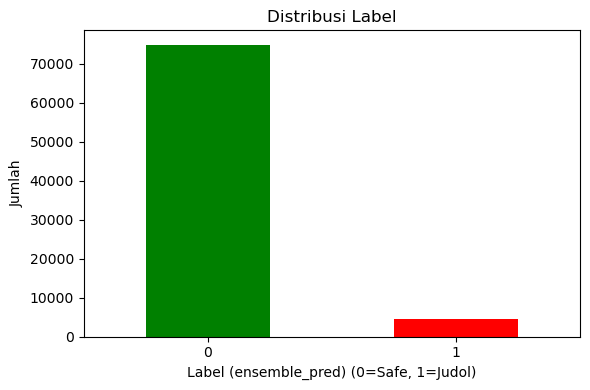

In [64]:
label_col = 'ensemble_pred' if 'comments_labeled_ensemble.csv' in file_path else 'label'

print('Distribusi Label:')
print(df[label_col].value_counts())
print(f"\nPersentase Judol: {df[label_col].mean()*100:.2f}%")

plt.figure(figsize=(6, 4))
df[label_col].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribusi Label')
plt.xlabel(f'Label ({label_col}) (0=Safe, 1=Judol)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

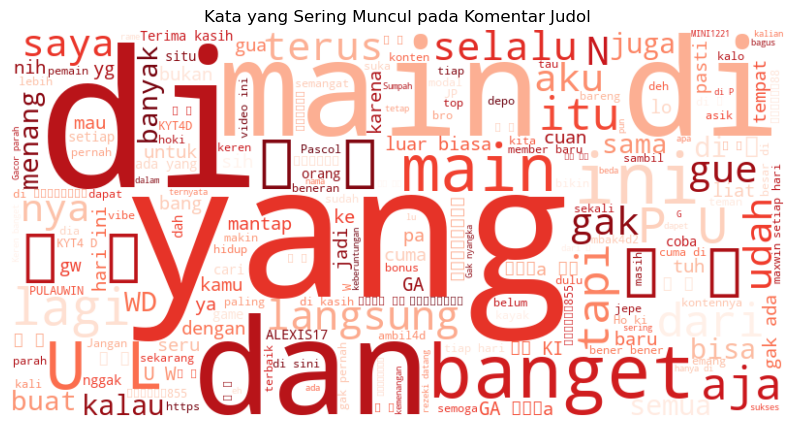

In [126]:
judol_comments = df[df['label'] == 1]['comment_text'].astype(str).str.cat(sep=' ')

# Buat WordCloud
plt.figure(figsize=(10, 6))
wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(judol_comments)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Kata yang Sering Muncul pada Komentar Judol')
plt.show()

In [67]:
df = df.dropna(subset=['comment_text', label_col])

X = df['comment_text'].astype(str)
y = df[label_col].astype(int)

print(f'Total samples: {len(X)}')
print(f'Judol (1): {y.sum()}')
print(f'Safe (0): {len(y) - y.sum()}')


Total samples: 79295
Judol (1): 4498
Safe (0): 74797


In [69]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train)}')
print(f'Test set: {len(X_test)}')

Training set: 63436
Test set: 15859


In [70]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    analyzer='char_wb',
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Train shape: {X_train_tfidf.shape}')

Vocabulary size: 10000
Train shape: (63436, 10000)


In [71]:
# Logistic Regression
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1: {f1_score(y_test, y_pred_lr):.4f}')

Training Logistic Regression...
Accuracy: 0.9804 | F1: 0.8466


In [72]:
# Naive Bayes
print('Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f} | F1: {f1_score(y_test, y_pred_nb):.4f}')

Training Naive Bayes...
Accuracy: 0.9829 | F1: 0.8378


In [73]:
# Random Forest
print('Training Random Forest...')
rf_model = RandomForestClassifier(n_estimators=100, max_depth=50, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1: {f1_score(y_test, y_pred_rf):.4f}')

Training Random Forest...
Accuracy: 0.9764 | F1: 0.7405


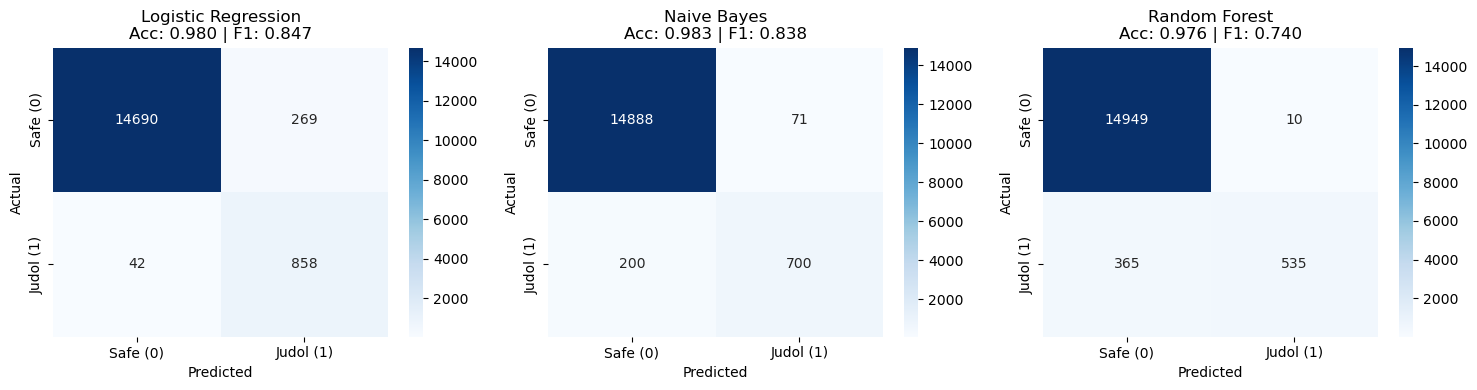

In [74]:
# Plot confusion matrix untuk semua TF-IDF models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_tfidf = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('Random Forest', y_pred_rf)
]

for ax, (name, y_pred) in zip(axes, models_tfidf):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Safe (0)', 'Judol (1)'],
                yticklabels=['Safe (0)', 'Judol (1)'])
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred):.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [77]:
# Classification Report - Best TF-IDF Model
print('=== Classification Report: Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Safe (0)', 'Judol (1)']))

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

    Safe (0)       1.00      0.98      0.99     14959
   Judol (1)       0.76      0.95      0.85       900

    accuracy                           0.98     15859
   macro avg       0.88      0.97      0.92     15859
weighted avg       0.98      0.98      0.98     15859



In [78]:
# Hyperparameters
MAX_WORDS = 20000
MAX_LEN = 100
EMBEDDING_DIM = 128

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, char_level=False, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size: {len(tokenizer.word_index)}')
print(f'Train shape: {X_train_pad.shape}')

Vocabulary size: 66864
Train shape: (63436, 100)


In [79]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f'Class weights: {class_weight_dict}')

Class weights: {0: np.float64(0.530064507503593), 1: np.float64(8.815453029460812)}


In [80]:
# Build Bidirectional LSTM model
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print(f'\nTraining stopped at epoch: {len(history.history["loss"])}')

Epoch 1/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 152s 160ms/step - accuracy: 0.9150 - loss: 0.2537 - val_accuracy: 0.9726 - val_loss: 0.0895
Epoch 2/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 143s 160ms/step - accuracy: 0.9749 - loss: 0.0923 - val_accuracy: 0.9696 - val_loss: 0.0777
Epoch 3/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 155s 174ms/step - accuracy: 0.9874 - loss: 0.0514 - val_accuracy: 0.9768 - val_loss: 0.0890
Epoch 4/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 178s 199ms/step - accuracy: 0.9894 - loss: 0.0439 - val_accuracy: 0.9732 - val_loss: 0.0939
Epoch 5/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 155s 173ms/step - accuracy: 0.9922 - loss: 0.0326 - val_accuracy: 0.9749 - val_loss: 0.0990
Epoch 6/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 166s 186ms/step - accuracy: 0.9929 - loss: 0.0283 - val_accuracy: 0.9782 - val_loss: 0.0800
Epoch 7/100
893/893 ━━━━━━━━━━━━━━━━━━━━ 160s 180ms/step - accuracy: 0.9947 - loss: 0.0284 - val_accuracy: 0.9582 - val_loss: 0.1432
Epoch 7: early stopping
Restoring model weights from the end of the b

In [82]:
metrics_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Loss': history.history['loss'],
    'Accuracy': history.history['accuracy'],
    'Val_Loss': history.history['val_loss'],
    'Val_Accuracy': history.history['val_accuracy']
})

print('=== LSTM Training Metrics per Epoch ===')
print(metrics_df.to_string(index=False))

best_epoch = metrics_df['Val_Loss'].idxmin() + 1
print(f'\nBest Epoch (lowest val_loss): {best_epoch}')
print(metrics_df.iloc[best_epoch-1])

=== LSTM Training Metrics per Epoch ===
 Epoch     Loss  Accuracy  Val_Loss  Val_Accuracy
     1 0.253664  0.915014  0.089455      0.972573
     2 0.092282  0.974918  0.077657      0.969578
     3 0.051433  0.987406  0.088982      0.976829
     4 0.043891  0.989403  0.093862      0.973203
     5 0.032640  0.992241  0.098963      0.974937
     6 0.028348  0.992924  0.080027      0.978247
     7 0.028449  0.994658  0.143241      0.958228

Best Epoch (lowest val_loss): 2
Epoch           2.000000
Loss            0.092282
Accuracy        0.974918
Val_Loss        0.077657
Val_Accuracy    0.969578
Name: 1, dtype: float64


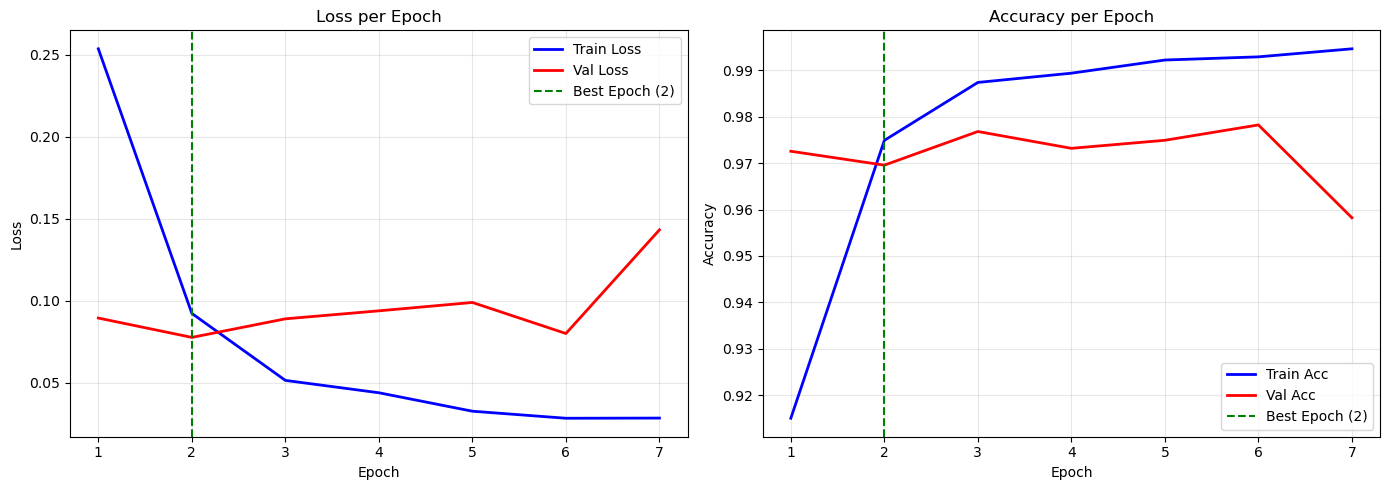

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics_df['Epoch'], metrics_df['Loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(metrics_df['Epoch'], metrics_df['Val_Loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_df['Epoch'], metrics_df['Accuracy'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(metrics_df['Epoch'], metrics_df['Val_Accuracy'], 'r-', label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [85]:
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

print(f'LSTM Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}')
print(f'LSTM F1-Score: {f1_score(y_test, y_pred_lstm):.4f}')

496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step
LSTM Accuracy: 0.9740
LSTM F1-Score: 0.7976


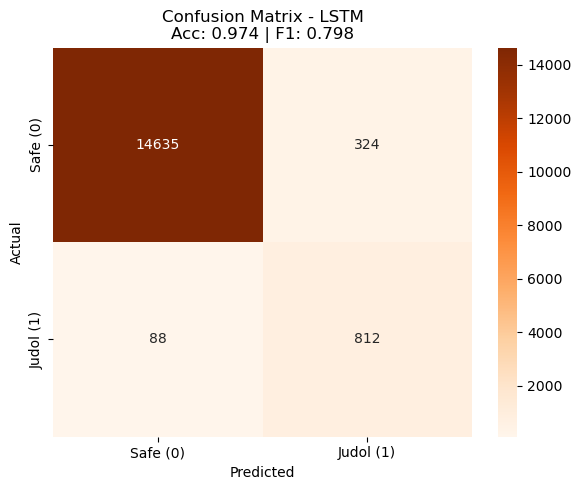


=== Classification Report: LSTM ===
              precision    recall  f1-score   support

    Safe (0)       0.99      0.98      0.99     14959
   Judol (1)       0.71      0.90      0.80       900

    accuracy                           0.97     15859
   macro avg       0.85      0.94      0.89     15859
weighted avg       0.98      0.97      0.98     15859



In [86]:
plt.figure(figsize=(6, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Safe (0)', 'Judol (1)'],
            yticklabels=['Safe (0)', 'Judol (1)'])
plt.title(f'Confusion Matrix - LSTM\nAcc: {accuracy_score(y_test, y_pred_lstm):.3f} | F1: {f1_score(y_test, y_pred_lstm):.3f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\n=== Classification Report: LSTM ===')
print(classification_report(y_test, y_pred_lstm, target_names=['Safe (0)', 'Judol (1)']))

In [87]:
# Compare all models
results = [
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_score(y_test, y_pred_lr), 'F1-Score': f1_score(y_test, y_pred_lr)},
    {'Model': 'Naive Bayes', 'Accuracy': accuracy_score(y_test, y_pred_nb), 'F1-Score': f1_score(y_test, y_pred_nb)},
    {'Model': 'Random Forest', 'Accuracy': accuracy_score(y_test, y_pred_rf), 'F1-Score': f1_score(y_test, y_pred_rf)},
    {'Model': 'Bidirectional LSTM', 'Accuracy': accuracy_score(y_test, y_pred_lstm), 'F1-Score': f1_score(y_test, y_pred_lstm)},
]

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print('\n=== MODEL COMPARISON ===')
print(results_df.to_string(index=False))


=== MODEL COMPARISON ===
              Model  Accuracy  F1-Score
Logistic Regression  0.980390  0.846571
        Naive Bayes  0.982912  0.837822
 Bidirectional LSTM  0.974021  0.797642
      Random Forest  0.976354  0.740484


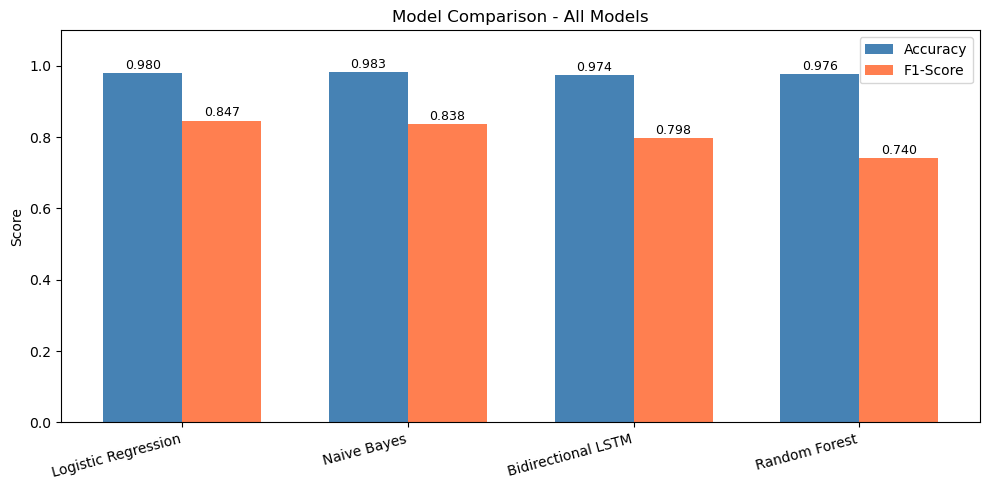

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Models')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [89]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(lr_model, '../models/judol_logreg_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

lstm_model.save('../models/judol_lstm_model.keras')
joblib.dump(tokenizer, '../models/lstm_tokenizer.pkl')

print('All models saved!')

All models saved!


In [90]:
def predict_tfidf(text):
    X = tfidf.transform([text])
    pred = lr_model.predict(X)[0]
    prob = lr_model.predict_proba(X)[0][1]
    return pred, prob

def predict_lstm(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob = lstm_model.predict(pad, verbose=0)[0][0]
    pred = 1 if prob > 0.5 else 0
    return pred, prob

# Test
test_comments = [
    'Video bagus bang, lanjutkan!',
    'Gaskeun join di MINI1221 banyak bonus!',
    'Buruan join di 𝐏𝐀𝐒𝐓𝐄𝟒𝐃 banyak cuan!',
    '2,8rb subs skrng pasti bakalan jutaan subs smangat',
    'Semangat terus kak, kontennya bagus!',
]

print('\n=== PREDICTION TEST ===')
print('-' * 80)
for comment in test_comments:
    pred_tf, prob_tf = predict_tfidf(comment)
    pred_lstm, prob_lstm = predict_lstm(comment)

    label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
    label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'

    print(f'Text: {comment[:50]}...')
    print(f'  TF-IDF: [{label_tf}] ({prob_tf:.2%})')
    print(f'  LSTM:   [{label_lstm}] ({prob_lstm:.2%})')
    print()


=== PREDICTION TEST ===
--------------------------------------------------------------------------------
Text: Video bagus bang, lanjutkan!...
  TF-IDF: [SAFE] (32.50%)
  LSTM:   [SAFE] (0.13%)

Text: Gaskeun join di MINI1221 banyak bonus!...
  TF-IDF: [JUDOL] (77.00%)
  LSTM:   [JUDOL] (99.96%)

Text: Buruan join di 𝐏𝐀𝐒𝐓𝐄𝟒𝐃 banyak cuan!...
  TF-IDF: [JUDOL] (99.93%)
  LSTM:   [JUDOL] (99.92%)

Text: 2,8rb subs skrng pasti bakalan jutaan subs smangat...
  TF-IDF: [SAFE] (22.45%)
  LSTM:   [JUDOL] (68.67%)

Text: Semangat terus kak, kontennya bagus!...
  TF-IDF: [SAFE] (33.21%)
  LSTM:   [SAFE] (9.49%)



In [119]:
def predict_ensemble(text):
    _, prob_tf = predict_tfidf(text)
    _, prob_lstm = predict_lstm(text)

    ensemble_prob = (0.6 * prob_tf) + (0.4 * prob_lstm)
    ensemble_pred = 1 if ensemble_prob > 0.5 else 0

    return ensemble_pred, ensemble_prob

print("Ensemble prediction function 'predict_ensemble' defined with weighted averaging.")

Ensemble prediction function 'predict_ensemble' defined with weighted averaging.


In [103]:
manual_comment = input('Masukkan komentar YouTube Anda: ')

print('\n=== MANUAL COMMENT PREDICTION ===')
print('-' * 80)

pred_tf, prob_tf = predict_tfidf(manual_comment)
pred_lstm, prob_lstm = predict_lstm(manual_comment)
pred_ensemble, prob_ensemble = predict_ensemble(manual_comment) # This now uses weighted average

label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'
label_ensemble = 'JUDOL' if pred_ensemble == 1 else 'SAFE'

print(f'Komentar: {manual_comment}')
print(f'  TF-IDF:   [{label_tf}] ({prob_tf:.2%})')
print(f'  LSTM:     [{label_lstm}] ({prob_lstm:.2%})')
print(f'  Ensemble: [{label_ensemble}] ({prob_ensemble:.2%})')

if label_tf != label_lstm or label_tf != label_ensemble or label_lstm != label_ensemble:
    print('  -> Ada perbedaan prediksi antar model!')
else:
    print('  -> Semua model setuju!')


=== MANUAL COMMENT PREDICTION ===
--------------------------------------------------------------------------------
Komentar: togel
  TF-IDF:   [JUDOL] (99.26%)
  LSTM:     [JUDOL] (97.74%)
  Ensemble: [JUDOL] (98.65%)
  -> Semua model setuju!


In [120]:
test_comments = [
    "Judi slot gacor hari ini pasti menang deposit 10k di link bio kami", # JUDOL
    "Selamat siang semua, jangan lupa makan siang ya! Ini adalah cuaca yang cerah sekali.", # NON-JUDOL
    "main di situs MPO444 sekarang dan langsung withdraw! dijamin jp", # JUDOL
    "video ini sangat bagus dan mengedukasi sekali tentang sejarah peradaban kuno di mesir.", # NON-JUDOL
    "Ayo join situs bola aman 11betting terpercaya di indonesia dan dapatkan bonus terbesar hari ini.", # JUDOL
    "Kapan episode selanjutnya tayang? Menunggu banget nih. Kami ingin tahu kelanjutannya.", # NON-JUDOL
    "link alternatif 77slot gampang menang nih bosku. klik link di bio.", # JUDOL
    "Selamat ulang tahun untuk teman baikku! Semoga panjang umur dan sehat selalu ya.", # NON-JUDOL
    "Ayo buruan daftar di MPO 7 77 sekarang, dapatkan bonus terbesar!", # JUDOL
    "WD 500rb di GACOR777 mantap langsung cair!", # JUDOL
    "buruan daftar di MANTAPJP888, depo 100k langsung dapat bonus!", # JUDOL
    "main slot pasti untung, depo terus bosku", # JUDOL
    "JP boss 44D mantap", # NON-JUDOL
    "S L 0 T P R 1 M A 8 8 8. Jp 100k wd cepat.", # JUDOL
    "Cepat gabung w1n k3lub, b4rus4n w d s4ld0 5j.", # JUDOL
    "Lagi gacor main di maxwin888 hari ini. Lomba makan.", # JUDOL (Target perbaikan 1)
    "Top banget! Terimakasih 𝗛𝗢𝗧𝗝𝗘𝗣𝗘𝟱𝟱 GOOD JOB!🀄🥰", # JUDOL (Target perbaikan 2)
    "WD 1O jt di BOSSku777. *lgsg cair*!", # JUDOL
    "Depo 100k, WD 20juta di RAJASLOT777. Pasti JP!", # JUDOL
    "Aku di MANTAP888. Gacor terus!", # JUDOL (Target perbaikan 3)
    "buruan daftar di MANTAPJEPE888 promonya gede banget", # JUDOL
    "Paling the best! HOTJEPE55 Memang GOOD JOB banget!", # JUDOL (Target perbaikan 4)
    "main di slotvip4d aja, depo 50 wd 500", # JUDOL
    "gacorwd77 adalah situs paling oke.", # JUDOL (Target perbaikan 5)
    "wd 1000 jp. link ada di bio ya.", # JUDOL
    "jp 2OOm jt sudah di WD. Paling gacor di sini.", # JUDOL
    "S L O T G A C O R 1 2 3 . C O M. Puji Tuhan, rejeki nomplok", # JUDOL
    "asli keren 𝗚𝗔𝗟𝗔𝗕𝗘𝗧𝟲𝟴𝟴 selalu bikin hepyy.", # JUDOL (Target perbaikan 6)
    "tokowin303 4w1 likeReply", # JUDOL (Target perbaikan 7)
    "Saya mau ngasih saran yg baik ya bg kemaren saya main di 𝙈𝘼𝙉𝙏𝙐𝙇𝟰𝟬𝟰 di kasih 22juta", # JUDOL (Target perbaikan 8)
    "𝗟𝗔𝗕𝗔𝟵𝟭 emang the real MVP, selalu bikin kita bahagia dengan kemenangan emang the real MVP, selalu bikin kita bahagia dengan kemenangan", # JUDOL (Target perbaikan 9)
    "slotvip777 depo 50 wd 500", # JUDOL
    "JP boss 44D mantap", # NON-JUDOL
    "💰 WD 5🟢0🟢0k di P U L A U W I N 88! Langsung 🤑 JP! Lomba", # JUDOL
    "S L 0 T G A C 0 R 1 2 3 --- jp 500k wd cepat", # JUDOL
    "𝗠𝗔𝗡𝗧𝗔𝗣𝗝𝗘𝗣𝗘𝟴𝟴🔥🔥 WD 2𝟬𝟬j", # JUDOL
    "W D   1 0 j t .. d i 𝗕𝗢𝗦𝗦𝗞𝘂777 !!", # JUDOL
    "jp besar 💵 WD kecil. Main di s l 0 t v 1 p 1 1 1 sekarang!", # JUDOL
    "p_υ_l_α_υ_w_ι_n88 💰 jp 10J cepat WD!!", # JUDOL
    "garudahoki🔥 mantapjepe888 🏆 jp 100k wd lancar", # JUDOL
    "wd sepuluh juta di slotvip111 🎯 langsung cair", # JUDOL
    "wd cepat + JP 200k main di RAJASLOT777 sekarang", # JUDOL
    "Daft4r di S G 1 ‧ 8‧8‧ bentar lagi ada drop mantap.", # JUDOL
    "mAin di b𝚘𝚜𝚔𝚞7𝟽𝟽 enak bet, wd aman.", # JUDOL
    "bo.s ku. tujuh tujuh tujuh lagi gila2an promo wdee.", # JUDOL
    "m​a​i​n​ ​d​i​ ​b​o​s​k​u​7​7​7​ g​a​s​k​e​n​.", # JUDOL
    "Coba deh di \"QlRTT1QxMDA=\" katanya jam 3 pagi gacor.", # JUDOL
    "Main di cptlv888 lumayan tarikannya. Lomba", # JUDOL (Target perbaikan 10)
    "我 在 博 司 苦 七星 七星 七星 刚 取 款.", # NON-JUDOL
    "b0sku77? gas bet wd ngebut bgt.", # JUDOL
    "b o s k u 7 7 7 ...disusun vertikal.", # JUDOL
    "WD 600 tadi, no cap. That site hits diff fr.", # JUDOL
    "M@!N di B0$KU^777 cuy wd kuzz teroosss.", # JUDOL
    "bo sku 7 7 7 — karena kamera burem jd gini.", # JUDOL
    "Beli skin game baru ah, keren nih!", # NON-JUDOL
    "Ini channel YouTube favoritku, sering update video baru.", # NON-JUDOL
    "Makan malam apa hari ini?", # NON-JUDOL
    "Saya mau nonton film gratis di y0utube, tapi juga WD 5 ribu dari tabungan", # NON-JUDOL
    "WD 50 ribu saja, buat beli kopi.", # NON-JUDOL
    "wah mantap nih, motor baru udah di WD sama pemiliknya", # NON-JUDOL
    "itu tempat bosku yang warna hijau itu loh, yg sering iklan jam 2 pagi.", # JUDOL (Target perbaikan 11)
    "Tadi malem aku pecah telur di tempat sebelah. Tarikan bersih bgt.", # JUDOL
    "Udah, masuk aja ke yang kemarin aku bilang. Yang tiap hari bagi hadiah itu.", # JUDOL
    "Wkwk mantap jp lagi di “platform terpercaya” itu katanya 🤡", # NON-JUDOL
    "bos ku sudah datang tadi pagi bawa hadiah 25k. Gila.", # NON-JUDOL
    "Ingat, keberanian itu modal. Kalau mau hasil besar, tempat itu udah aku rekomendasiin kemarin.", # JUDOL
    "Semoga sukses selalu dan sehat terus ya. Kontennya sangat bermanfaat!", # NON-JUDOL
    "Saya transfer 500 ribu ke rekening teman tadi pagi, semoga lancar.", # NON-JUDOL
    "Main Mobile Legends seru banget, tapi harus top up dulu buat beli diamond.", # NON-JUDOL
    "Saya pesan nasi Padang di warung Bossku tadi, rasanya mantap.", # NON-JUDOL
    "Saya sudah JP (Jelas Puas) sama pelayanan toko ini.", # NON-JUDOL
    "Komentar ini hanya berisi pujian, tidak ada unsur promosi atau judi.", # NON-JUDOL
    "link untuk download materi kuliah ada di deskripsi video ya teman-teman.", # NON-JUDOL
    "Terima kasih atas video tutorial cara WD (Withdrawal) uang dari platform saham.", # NON-JUDOL
    "Dijamin happy udah kaya rumah kedua 𝐀𝐑𝐄𝐍𝐀𝟗𝟐𝟑 disini 👏", # JUDOL (Target perbaikan 12)
    "cuma di tempat lu bang yang paling amanah🙌", # JUDOL
    "𝙈𝙀𝙂𝘼𝘽𝙀𝙏𝟭𝟴𝟵 emang the real MVP selalu bikin kita bahagia dengan kemenangannya", # JUDOL (Target perbaikan 13)
    "Tadi pagi aku WD (Withdraw) uang tunai dari ATM 500 ribu.", # NON-JUDOL
    "WD dana beasiswa sudah cair, total 5 juta! Alhamdulillah.", # NON-JUDOL
    "Jangan lupa WD hasil penjualan dari platform e-commerce itu ya.", # NON-JUDOL
    "Pelayanan toko ini JP (Jelas Puas) banget, barangnya 'Gacor'!", # NON-JUDOL
    "Aku JP (Jaminan Produk) 100% kalau kamu beli di Bossku Official Store.", # NON-JUDOL
    "Wah, si Bossku tadi pagi datang bawa hadiah, mantap JP!", # NON-JUDOL
    "Motor baruku Gacor banget, tarikannya mantap!", # NON-JUDOL
    "Si Bossku (panggilan teman) tadi Depo (Deposit) makanan ke meja.", # NON-JUDOL
    "Restoran ini Gacor tiap hari, ramenya nggak ketulungan.", # NON-JUDOL
    "Aku dapat promo Depo 50k, dapat 50k di Toko X (bukan situs judi).", # NON-JUDOL
    "Gacor banget, main game Mobile Legends dapat JP (Juara Pertama).", # NON-JUDOL
    "Kata Bossku, ini adalah situs terbaik untuk beli akun game (bukan judi).", # NON-JUDOL
    "WD 5 ribu aja buat beli kopi, soalnya dompet udah 'Gacor'." # NON-JUDOL
]

print('\n=== BATCH COMMENT PREDICTION ===')
print('-' * 80)

for comment in test_comments:
    pred_tf, prob_tf = predict_tfidf(comment)
    pred_lstm, prob_lstm = predict_lstm(comment)
    pred_ensemble, prob_ensemble = predict_ensemble(comment)

    label_tf = 'JUDOL' if pred_tf == 1 else 'SAFE'
    label_lstm = 'JUDOL' if pred_lstm == 1 else 'SAFE'
    label_ensemble = 'JUDOL' if pred_ensemble == 1 else 'SAFE'

    print(f'Komentar: {comment}')
    print(f'  TF-IDF:   [{label_tf}] ({prob_tf:.2%})')
    print(f'  LSTM:     [{label_lstm}] ({prob_lstm:.2%})')
    print(f'  Ensemble: [{label_ensemble}] ({prob_ensemble:.2%})')

    if label_tf != label_lstm or label_tf != label_ensemble or label_lstm != label_ensemble:
        print('  -> Ada perbedaan prediksi antar model!\n')
    else:
        print('  -> Semua model setuju!\n')



=== BATCH COMMENT PREDICTION ===
--------------------------------------------------------------------------------
Komentar: Judi slot gacor hari ini pasti menang deposit 10k di link bio kami
  TF-IDF:   [JUDOL] (99.19%)
  LSTM:     [JUDOL] (99.84%)
  Ensemble: [JUDOL] (99.45%)
  -> Semua model setuju!

Komentar: Selamat siang semua, jangan lupa makan siang ya! Ini adalah cuaca yang cerah sekali.
  TF-IDF:   [JUDOL] (83.66%)
  LSTM:     [SAFE] (19.11%)
  Ensemble: [JUDOL] (57.84%)
  -> Ada perbedaan prediksi antar model!

Komentar: main di situs MPO444 sekarang dan langsung withdraw! dijamin jp
  TF-IDF:   [JUDOL] (99.24%)
  LSTM:     [JUDOL] (99.96%)
  Ensemble: [JUDOL] (99.53%)
  -> Semua model setuju!

Komentar: video ini sangat bagus dan mengedukasi sekali tentang sejarah peradaban kuno di mesir.
  TF-IDF:   [SAFE] (16.36%)
  LSTM:     [SAFE] (0.52%)
  Ensemble: [SAFE] (10.02%)
  -> Semua model setuju!

Komentar: Ayo join situs bola aman 11betting terpercaya di indonesia dan dapatk

In [59]:
import pandas as pd
from tqdm.notebook import tqdm

# Re-load the dataset as df was not defined in the previous execution
df = pd.read_csv('../datasets/comments_labeled_final.csv')

# Ensure comment_text is string and label is int, as per previous preprocessing steps
df = df.dropna(subset=['comment_text', 'label'])
df['comment_text'] = df['comment_text'].astype(str)
df['label'] = df['label'].astype(int)

# Initialize new columns
df['ensemble_pred'] = None
df['ensemble_prob'] = None

# Iterate through each row and apply predict_ensemble
# Using tqdm for progress tracking as the dataframe is large
for index, row in tqdm(df.iterrows(), total=len(df), desc='Generating Ensemble Predictions'):
    comment = row['comment_text'] # comment is already string due to preprocessing above
    pred, prob = predict_ensemble(comment)

    df.loc[index, 'ensemble_pred'] = pred
    df.loc[index, 'ensemble_prob'] = prob

# Ensure ensemble_pred column is of integer type
df['ensemble_pred'] = df['ensemble_pred'].astype(int)

print("Ensemble predictions generated and added to the DataFrame 'df'.")
print(df[['comment_text', 'label', 'ensemble_pred', 'ensemble_prob']].head())
df.to_csv('../datasets/comments_labeled_ensemble.csv', index=False)

Generating Ensemble Predictions:   0%|          | 0/79295 [00:00<?, ?it/s]

Ensemble predictions generated and added to the DataFrame 'df'.
                                        comment_text  label  ensemble_pred  \
0  Maaf bang tapi sekarang km udah gak natural ba...      0              0   
1  Kontennya keren! Terus berkarya bang 🙌\r\nSala...      1              1   
2              Giliran yg lucu waktu nya cepet bngt😢      0              0   
3                                Eh ada Pak jalal 😂😂      0              0   
4  Sekilas anakNya jarwo mirip te ocah yh..tau cM...      0              0   

  ensemble_prob  
0      0.103018  
1      0.997857  
2      0.050322  
3      0.007871  
4      0.018884  
